# Phase 8 — Uplift (Causal) Modeling

The Phase 4 churn model predicts `P(churn | user)`. The Phase 6 decision rule then
multiplies that by an **assumed uplift constant** (e.g., 15% for `credit_5`) to size
the retention lever. That assumption has two flaws:

1. **Real uplift is heterogeneous.** A payment-issue user responds very differently
   to a credit than a heavy viewer does.
2. **Some users are "sleeping dogs"** — the retention nudge actually *increases*
   their churn (reminds them to cancel). A propensity-only model can't spot these.

Uplift modeling estimates the **causal treatment effect per user** directly from a
randomized experiment. In Phase 8 we:

- Train **four uplift meta-learners** (S-, T-, X-, ClassTransformation) on the
  `credit_5` lever using the experimental data the simulator now provides.
- Compare them on **Qini AUC** and **retention-lift-at-K**.
- Pick a winner and save the fitted model for Phase 6 to consume.
- Sanity-check by inspecting the **persuadable / sleeping-dog** split.

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load experimental data, filter to `credit_5` arm |
| **B. Bake-off** | Train four uplift learners, all tracked in MLflow |
| **C. Comparison** | Cross-model table + Qini curves |
| **D. Inspection** | Persuadable vs sleeping-dog deep-dive |
| **E. Persist** | Save winner for Phase 6 to consume |
| **F. Verdict** | Final call + Phase 6 handoff |

Runs land in the local MLflow store (`mlflow.db`), experiment `streamflix_churn`.
Launch `mlflow ui` from the project root to browse.

In [1]:
import os
import sys
import pickle
from pathlib import Path

# Run from project root whether invoked as `python notebooks/08_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers_experiment
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.uplift import (
    train_s_learner, train_t_learner, train_x_learner,
    train_class_transformation, predict_uplift,
)
from src.models.evaluate import compute_uplift_metrics, qini_curve_points
from src.models.tracking import mlflow_run, register_production_model
from src.models.production import (
    UPLIFT_MODEL_PATH, UPLIFT_MODEL_ARTIFACT_KEY,
    UPLIFT_MODEL_REGISTRY_NAME, UPLIFT_FOCUS_LEVER,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# We focus this notebook on ONE lever (credit_5) so the uplift model has
# a clean binary treatment. Multi-lever uplift is a v1.1 extension.
# Sourced from src/models/production.py so the lever choice, the pickle
# path, and the Registry name all stay in sync.
FOCUS_LEVER = UPLIFT_FOCUS_LEVER

## A. Setup — load experimental data, filter to focus lever

In [2]:
print("=" * 70)
print(f"A. SETUP (focus lever: {FOCUS_LEVER})")
print("=" * 70)

# Phase 8 uses the EXPERIMENT dataset (data/subscribers_experiment.csv),
# not the baseline file that Phase 4-6 use. The extra 5 columns
# (treated, treatment_lever, churned_if_treated, y_observed, true_uplift)
# are what turns this into a causal-inference problem instead of a
# propensity problem.
raw = load_subscribers_experiment("data/subscribers_experiment.csv")
df = build_features(raw)

# Keep control users + treated users who got the FOCUS_LEVER
lever_mask = (df["treatment_lever"] == "none") | (df["treatment_lever"] == FOCUS_LEVER)
sub = df[lever_mask].reset_index(drop=True)

X, _ = prepare_features(sub)
y = sub["y_observed"].values.astype(int)
t = sub["treated"].values.astype(int)

print(f"Total users        : {len(sub):,}")
print(f"  control (t=0)    : {(t == 0).sum():,}")
print(f"  treated (t=1)    : {(t == 1).sum():,}  (all got {FOCUS_LEVER})")
print(f"Naive ATE          : "
      f"{sub.loc[t == 0, 'y_observed'].mean() - sub.loc[t == 1, 'y_observed'].mean():+.4f}")
print(f"  (control_churn - treated_churn, higher = treatment helps)")

# Train / test split, stratified on treatment
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.30, stratify=t, random_state=42,
)
print(f"\nTrain: {len(X_train):,}   Test: {len(X_test):,}")

A. SETUP (focus lever: credit_5)
Total users        : 29,996
  control (t=0)    : 24,946
  treated (t=1)    : 5,050  (all got credit_5)
Naive ATE          : +0.0401
  (control_churn - treated_churn, higher = treatment helps)

Train: 20,997   Test: 8,999


## B. Train four uplift meta-learners (bake-off)

S-, T-, X-learner + ClassTransformation, all tracked in MLflow.

In [3]:
print("\n" + "=" * 70)
print("B. UPLIFT BAKE-OFF (S / T / X / ClassTransformation)")
print("=" * 70)

learners = {
    "s_learner":      train_s_learner,
    "t_learner":      train_t_learner,
    "x_learner":      train_x_learner,
    "class_transform": train_class_transformation,
}

results = {}     # {name: metrics_dict}
predictions = {} # {name: uplift_on_test}
fitted = {}      # {name: model}
run_ids = {}     # {name: mlflow_run_id} -- captured for Registry promotion below

for name, trainer_fn in learners.items():
    with mlflow_run(f"uplift_{name}") as run:
        model = trainer_fn(X_train, t_train, y_train)
        u = predict_uplift(model, X_test)
        metrics = compute_uplift_metrics(y_test, u, t_test)
        if run is not None:
            run.log_params({
                "model_type": f"uplift_{name}",
                "focus_lever": FOCUS_LEVER,
                "base_estimator": "HistGradientBoostingClassifier",
                "n_train": len(X_train),
                "n_test": len(X_test),
            })
            run.log_metrics(metrics)
            try:
                run.log_model(model, name="uplift_model")
            except Exception as e:
                print(f"  (model log skipped for {name}: {e})")
            # Capture run_id WHILE the run is active. We use it after the
            # winner is picked (Section C) to promote to the Registry.
            run_ids[name] = run.run_id
    results[name] = metrics
    predictions[name] = u
    fitted[name] = model
    print(f"  {name:<18} qini_auc={metrics['qini_auc']:>+.4f}  "
          f"lift@30={metrics['retention_lift_at_30pct']:>+.4f}  "
          f"lift@10={metrics['retention_lift_at_10pct']:>+.4f}")


B. UPLIFT BAKE-OFF (S / T / X / ClassTransformation)
  s_learner          qini_auc=+0.0131  lift@30=+0.0759  lift@10=+0.0853
  t_learner          qini_auc=+0.0145  lift@30=+0.0771  lift@10=+0.1102
  x_learner          qini_auc=+0.0142  lift@30=+0.0766  lift@10=+0.1022
  class_transform    qini_auc=+0.0122  lift@30=+0.0730  lift@10=+0.0933


## C. Cross-model comparison + Qini curves


C. COMPARISON TABLE + QINI CURVES

                  qini_auc  retention_lift_at_30pct  retention_lift_at_10pct
t_learner          0.0145                   0.0771                   0.1102
x_learner          0.0142                   0.0766                   0.1022
s_learner          0.0131                   0.0759                   0.0853
class_transform    0.0122                   0.0730                   0.0933 

Saved -> reports\figures/08_qini_curves.png


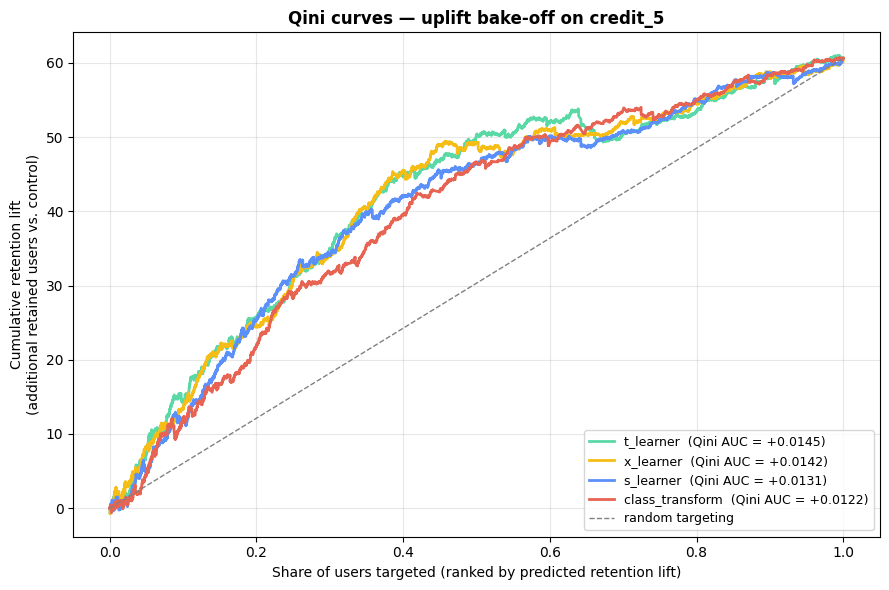

In [4]:
print("\n" + "=" * 70)
print("C. COMPARISON TABLE + QINI CURVES")
print("=" * 70)

comparison = pd.DataFrame(results).T.round(4)
comparison = comparison.sort_values("qini_auc", ascending=False)
print("\n", comparison, "\n")

# Qini curves for all four models
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"s_learner": "#5B8FF9", "t_learner": "#5AD8A6",
          "x_learner": "#F6BD16", "class_transform": "#E86452"}

for name in comparison.index:
    qc = qini_curve_points(y_test, predictions[name], t_test)
    label = f"{name}  (Qini AUC = {results[name]['qini_auc']:+.4f})"
    ax.plot(qc["share_targeted"], qc["cumulative_retention_lift"],
            color=colors.get(name, "gray"), lw=2, label=label)

# Random baseline: diagonal from (0,0) to (1, total_effect)
total_effect_line_end = qc["cumulative_retention_lift"].iloc[-1]
ax.plot([0, 1], [0, total_effect_line_end], color="gray",
        ls="--", lw=1, label="random targeting")

ax.set_xlabel("Share of users targeted (ranked by predicted retention lift)")
ax.set_ylabel("Cumulative retention lift\n(additional retained users vs. control)")
ax.set_title(f"Qini curves — uplift bake-off on {FOCUS_LEVER}",
             fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_qini_curves.png", dpi=140, bbox_inches="tight")
print(f"Saved -> {FIG_DIR}/08_qini_curves.png")
plt.show()

## D. Persuadable vs sleeping-dog inspection

Decile view: does the winner's ranking actually catch the persuadables?


D. PERSUADABLE vs SLEEPING-DOG INSPECTION

Inspection uses the WINNER: t_learner

Decile view (10 = top-predicted persuadables, 0 = bottom):
decile  n_users  pred_lift ctrl_churn trmt_churn actual_lift
--------------------------------------------------------------
     9      900    +0.1619     0.2016     0.0916     +0.1100
     8      900    +0.0754     0.0874     0.0256     +0.0617
     7      900    +0.0515     0.0573     0.0120     +0.0453
     6      900    +0.0379     0.0544     0.0000     +0.0544
     5      899    +0.0281     0.0514     0.0071     +0.0442
     4      900    +0.0212     0.0341     0.0146     +0.0195
     3      900    +0.0159     0.0183     0.0224     -0.0041
     2      900    +0.0109     0.0135     0.0000     +0.0135
     1      900    +0.0059     0.0269     0.0000     +0.0269
     0      900    -0.0011     0.0164     0.0060     +0.0104

Saved -> reports\figures/08_decile_lift.png


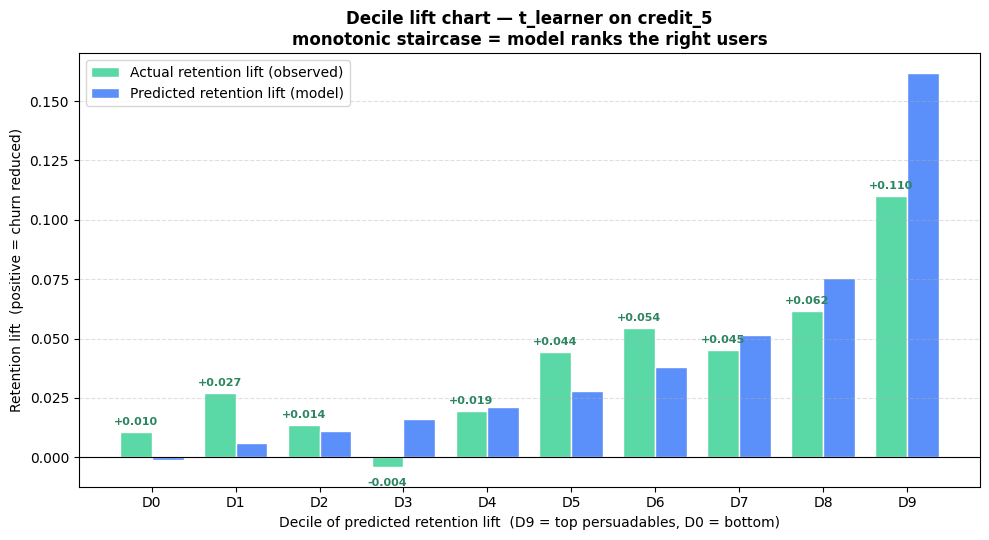


Users with predicted retention lift > +0.02 (persuadables): 5,137 (57.1%)
Users with predicted retention lift < -0.02 (sleeping dogs): 4 (0.0%)


In [5]:
print("\n" + "=" * 70)
print("D. PERSUADABLE vs SLEEPING-DOG INSPECTION")
print("=" * 70)

winner_name = comparison.index[0]
winner_uplift = predictions[winner_name]
print(f"\nInspection uses the WINNER: {winner_name}")

# Convert to retention lift (positive = good) for intuitive quantiles
retention_lift = -winner_uplift

# Decile buckets
deciles = pd.qcut(retention_lift, q=10, labels=False, duplicates="drop")
buckets = pd.DataFrame({
    "decile": deciles,
    "predicted_retention_lift": retention_lift,
    "y_observed": y_test,
    "treated": t_test,
})

print("\nDecile view (10 = top-predicted persuadables, 0 = bottom):")
print(f"{'decile':>6} {'n_users':>8} {'pred_lift':>10} "
      f"{'ctrl_churn':>10} {'trmt_churn':>10} {'actual_lift':>11}")
print("-" * 62)
decile_rows = []
for d in sorted(buckets["decile"].unique(), reverse=True):
    b = buckets[buckets["decile"] == d]
    ctrl = b[b["treated"] == 0]["y_observed"].mean()
    trmt = b[b["treated"] == 1]["y_observed"].mean()
    actual = ctrl - trmt
    predicted = b["predicted_retention_lift"].mean()
    decile_rows.append({"decile": int(d), "n": len(b), "predicted": predicted,
                        "ctrl_churn": ctrl, "trmt_churn": trmt, "actual": actual})
    print(f"{int(d):>6} {len(b):>8,} {predicted:>+10.4f} "
          f"{ctrl:>10.4f} {trmt:>10.4f} {actual:>+11.4f}")
decile_df = pd.DataFrame(decile_rows).sort_values("decile")

# Decile lift chart -- visualizes the printed table above
fig, ax = plt.subplots(figsize=(10, 5.5))
x_pos = np.arange(len(decile_df))
bar_width = 0.38
bars_actual = ax.bar(x_pos - bar_width / 2, decile_df["actual"],
                     bar_width, color="#5AD8A6",
                     edgecolor="white", label="Actual retention lift (observed)")
bars_pred = ax.bar(x_pos + bar_width / 2, decile_df["predicted"],
                   bar_width, color="#5B8FF9",
                   edgecolor="white", label="Predicted retention lift (model)")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"D{d}" for d in decile_df["decile"]])
ax.set_xlabel("Decile of predicted retention lift  (D9 = top persuadables, D0 = bottom)")
ax.set_ylabel("Retention lift  (positive = churn reduced)")
ax.set_title(f"Decile lift chart — {winner_name} on {FOCUS_LEVER}\n"
             "monotonic staircase = model ranks the right users",
             fontweight="bold")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Value labels on the actual-lift bars (the ones the business cares about)
for bar, v in zip(bars_actual, decile_df["actual"]):
    y_pos = v + (0.003 if v >= 0 else -0.008)
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            f"{v:+.3f}", ha="center", fontsize=8,
            color="#2c8560", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_decile_lift.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/08_decile_lift.png")
plt.show()

# Sleeping-dog check: bottom decile should show actual_lift close to 0
# or NEGATIVE (treatment hurts these users). If our model works, the top
# decile should show much larger actual lift than the bottom decile.
n_persuadables = int((retention_lift > 0.02).sum())
n_sleeping_dogs = int((retention_lift < -0.02).sum())
print(f"\nUsers with predicted retention lift > +0.02 (persuadables): "
      f"{n_persuadables:,} ({n_persuadables / len(retention_lift):.1%})")
print(f"Users with predicted retention lift < -0.02 (sleeping dogs): "
      f"{n_sleeping_dogs:,} ({n_sleeping_dogs / len(retention_lift):.1%})")

## E. Persist winner for Phase 6 to consume

In [6]:
print("\n" + "=" * 70)
print("E. PERSIST WINNER")
print("=" * 70)

# Persist to the path declared in src/models/production.py so every
# downstream consumer (uplift-aware policy, future uplift-aware Streamlit
# tab) loads exactly this artifact.
winner_model = fitted[winner_name]
UPLIFT_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(UPLIFT_MODEL_PATH, "wb") as f:
    pickle.dump({
        UPLIFT_MODEL_ARTIFACT_KEY: winner_model,   # <- key that loader reads
        "model_type":              winner_name,
        "focus_lever":             FOCUS_LEVER,
        "feature_names":           list(X.columns),
        "metrics_test":            results[winner_name],
    }, f)
print(f"Saved winner ({winner_name}) -> {UPLIFT_MODEL_PATH}")

# Promote the winner to the MLflow Model Registry using the run_id we
# captured during the bake-off loop. Downstream jobs can load
# `models:/{UPLIFT_MODEL_REGISTRY_NAME}@production` without a run ID.
# The pickle stays as the portable deploy-time artifact.
winner_run_id = run_ids.get(winner_name)
register_production_model(
    winner_run_id,
    UPLIFT_MODEL_REGISTRY_NAME,
    artifact_name="uplift_model",
)


E. PERSIST WINNER
Saved winner (t_learner) -> models\uplift_credit_5_v1.pkl


Registered model 'streamflix_uplift_credit_5' already exists. Creating a new version of this model...
2026/08/09 00:47:22 WARNING mlflow.tracking._model_registry.fluent: Run with id f7e2ac46d55f4cba9933f50b61a9f6b3 has no artifacts at artifact path 'uplift_model', registering model based on models:/m-3d9f4627a8db4b379a1755d84f6b7d48 instead


  Registry: streamflix_uplift_credit_5 v4 tagged @production (verified)


Created version '4' of model 'streamflix_uplift_credit_5'.


## F. Verdict + Phase 6 handoff

In [7]:
print("\n" + "=" * 70)
print("F. VERDICT + PHASE 6 HANDOFF")
print("=" * 70)
print(f"""
Winner on Qini AUC: {winner_name}
  Qini AUC          : {results[winner_name]['qini_auc']:+.4f}
  Retention lift @30%: {results[winner_name]['retention_lift_at_30pct']:+.4f}
  Retention lift @10%: {results[winner_name]['retention_lift_at_10pct']:+.4f}

Interpretation:
  Random ranker would score Qini AUC = 0. A positive score means our
  model ranks users better than random when picking who to treat.
  Retention lift @10% = additional retained users per targeted user
  vs. random targeting -- directly the ROI upside for a tight budget.

Phase 6 handoff:
  Load models/uplift_{FOCUS_LEVER}_v1.pkl in the decision-rule notebook
  and replace the constant `uplift` field in INTERVENTION_MENU with
  the per-user predicted retention lift. See pick_best_lever_uplift()
  in src/decisions/policy.py.

MLflow: browse runs under experiment 'streamflix_churn' in `mlflow ui`.
""")


F. VERDICT + PHASE 6 HANDOFF

Winner on Qini AUC: t_learner
  Qini AUC          : +0.0145
  Retention lift @30%: +0.0771
  Retention lift @10%: +0.1102

Interpretation:
  Random ranker would score Qini AUC = 0. A positive score means our
  model ranks users better than random when picking who to treat.
  Retention lift @10% = additional retained users per targeted user
  vs. random targeting -- directly the ROI upside for a tight budget.

Phase 6 handoff:
  Load models/uplift_credit_5_v1.pkl in the decision-rule notebook
  and replace the constant `uplift` field in INTERVENTION_MENU with
  the per-user predicted retention lift. See pick_best_lever_uplift()
  in src/decisions/policy.py.

MLflow: browse runs under experiment 'streamflix_churn' in `mlflow ui`.

